In [1]:
!date

Thu Sep 17 10:44:46 PDT 2026


In [2]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
projdir = '/u/project/cluo/terencew/claude/project_ideas/asm_lr_hprc2'
figdir = f'{projdir}/figures/pmds'
outdir = f'{projdir}/results/qc/data/qc13'
!mkdir -p {outdir}

### donor covariates (B01b donors.tsv) + cell line era proxy

In [4]:
cov = pd.read_csv(f'{projdir}/results/meth_bins/donors.tsv', sep='\t')
pops = pd.read_csv(f'{projdir}/tsv/meta/hprc2_sample_manifest.tsv', sep='\t').set_index('sample_id')['population']
cov['population'] = cov['sample'].map(pops)
# no age for these donors (Coriell: 'Age: No Data'); NA vs HG Coriell prefix ~ banking era (NA = HapMap-era lines)
cov['id_prefix'] = cov['sample'].str[:2]
hapmap12 = ['CEU', 'YRI', 'CHB', 'JPT']
hapmap3 = ['ASW', 'CHD', 'GIH', 'LWK', 'MXL', 'MKK', 'TSI']
cov['collection'] = np.select([cov['population'].isin(hapmap12), cov['population'].isin(hapmap3)], ['HapMap1-2', 'HapMap3'], '1000G')

In [5]:
cov.head()

,sample,superpopulation,chemistry,read_N50_ont,sex,passage,established,hprc2_meth_qc_flag,global_meth,mean_depth,pmd_burden_bp,frac_cpg_in_pmd,map_rate,population,id_prefix,collection
0,HG00097,EUR,R1041,89210.35,female,5.0,External,0,0.520791,25.406927,1.550922e+09,0.403401,0.821983,GBR,HG,1000G
1,HG00099,EUR,R941,72139.93,female,5.0,External,0,0.518563,27.449030,1.322907e+09,0.335799,0.817794,GBR,HG,1000G
2,HG00126,EUR,R1041,107245.82,male,5.0,External,0,0.529499,33.732242,1.347435e+09,0.358318,0.835642,GBR,HG,1000G
3,HG00128,EUR,R1041,92413.37,female,5.0,External,0,0.522023,26.792516,1.611503e+09,0.444308,0.821778,GBR,HG,1000G
4,HG00133,EUR,R1041,105700.81,female,5.0,External,0,0.528512,31.055373,1.391396e+09,0.356709,0.833830,GBR,HG,1000G


In [6]:
cov.shape

(201, 16)

In [7]:
cov[['chemistry', 'sex', 'established', 'id_prefix', 'collection', 'superpopulation']].apply(lambda x: x.value_counts(dropna=False).to_dict())

chemistry                                 {'R941': 146, 'R1041': 55}
sex                              {'female': 96, 'male': 92, nan: 13}
established                {'Coriell': 135, nan: 45, 'External': 21}
id_prefix                                      {'HG': 156, 'NA': 45}
collection            {'1000G': 156, 'HapMap3': 29, 'HapMap1-2': 16}
superpopulation    {'AFR': 54, 'AMR': 40, 'EAS': 38, 'SAS': 36, '...
dtype: object

In [8]:
cov['passage'].value_counts(dropna=False)

5.0    144
NaN     46
3.0      6
6.0      4
7.0      1
Name: passage, dtype: int64

In [9]:
pd.crosstab(cov['id_prefix'], cov['chemistry'])

chemistry,R1041,R941
id_prefix,,
HG,25,131
NA,30,15


### PMD expansion metrics per donor

In [10]:
z = np.load(f'{projdir}/results/meth_bins/donor_bin_meth_10kb.npz', allow_pickle=True)
meth, pmd, donors = z['meth'], z['pmd'], list(z['donors'])
freq = pd.read_csv(f'{projdir}/results/meth_bins/domain_frequency_10kb.tsv.gz', sep='\t')
cls = freq['class_pmd'].values
meth.shape, freq.shape

((201, 265052), (265052, 14))

In [11]:
never_med = np.nanmedian(meth[:, cls == 'never'], axis=1)
low_rel = meth < (never_med[:, None] - 0.15)
m = pd.DataFrame({'sample': donors})
m['mcg_never'] = np.nanmean(meth[:, cls == 'never'], axis=1)
m['mcg_constitutive'] = np.nanmean(meth[:, cls == 'constitutive'], axis=1)
m['mcg_variable'] = np.nanmean(meth[:, cls == 'variable'], axis=1)
m['mcg_rare'] = np.nanmean(meth[:, cls == 'rare'], axis=1)
m['depth_constitutive'] = m['mcg_never'] - m['mcg_constitutive']
m['depth_variable'] = m['mcg_never'] - m['mcg_variable']
m['depth_rare'] = m['mcg_never'] - m['mcg_rare']
m['breadth_lt0.5'] = np.nanmean(meth < 0.5, axis=1)
m['breadth_lt0.6'] = np.nanmean(meth < 0.6, axis=1)
m['breadth_rel'] = np.nanmean(low_rel, axis=1)
nc = cls != 'constitutive'
m['spread_outside_constitutive'] = np.nanmean(low_rel[:, nc], axis=1)
m['own_pmd_bin_frac'] = np.nanmean(pmd >= 0.5, axis=1)
m = m.merge(cov, on='sample', how='left')

In [12]:
m.head()

,sample,mcg_never,mcg_constitutive,mcg_variable,mcg_rare,depth_constitutive,depth_variable,depth_rare,breadth_lt0.5,breadth_lt0.6,...,established,hprc2_meth_qc_flag,global_meth,mean_depth,pmd_burden_bp,frac_cpg_in_pmd,map_rate,population,id_prefix,collection
0,HG00097,0.778194,0.532610,0.603890,0.648395,0.245584,0.174304,0.129798,0.196346,0.467882,...,External,0,0.520791,25.406927,1.550922e+09,0.403401,0.821983,GBR,HG,1000G
1,HG00099,0.789830,0.591849,0.659184,0.688841,0.197980,0.130646,0.100989,0.090726,0.302461,...,External,0,0.518563,27.449030,1.322907e+09,0.335799,0.817794,GBR,HG,1000G
2,HG00126,0.782072,0.593786,0.653631,0.682833,0.188286,0.128441,0.099239,0.087115,0.304393,...,External,0,0.529499,33.732242,1.347435e+09,0.358318,0.835642,GBR,HG,1000G
3,HG00128,0.788791,0.552431,0.626630,0.666893,0.236361,0.162161,0.121899,0.153676,0.413779,...,External,0,0.522023,26.792516,1.611503e+09,0.444308,0.821778,GBR,HG,1000G
4,HG00133,0.787096,0.585918,0.652731,0.686317,0.201178,0.134365,0.100780,0.096075,0.321514,...,External,0,0.528512,31.055373,1.391396e+09,0.356709,0.833830,GBR,HG,1000G


In [13]:
m.shape

(201, 28)

### boundary spread from metagene flanks (A01f; only haplotypes processed so far)

In [14]:
rows = []
for f in sorted(glob.glob(f'{projdir}/results/pmd_metagene/per_hap/*_hap1.npz')):
    a = np.load(f)['lcl_constitutive_ge300kb'].astype(float)
    p = np.nanmean(a, axis=0)
    inner = np.r_[p[15:20], p[60:65]].mean()     # 0-50kb outside the domain
    outer = np.r_[p[0:5], p[75:80]].mean()       # 150-200kb outside
    body = p[20:60].mean()
    rows.append({'sample': f.split('/')[-1].replace('_hap1.npz', ''), 'flank_inner': inner, 'flank_outer': outer, 'body': body})
bs = pd.DataFrame(rows)
if len(bs):
    bs['boundary_spread'] = (bs['flank_outer'] - bs['flank_inner']) / (bs['flank_outer'] - bs['body'])
    m = m.merge(bs[['sample', 'boundary_spread']], on='sample', how='left')
len(bs)

1

### how the metrics relate to each other

In [15]:
metrics = ['global_meth', 'depth_constitutive', 'depth_variable', 'depth_rare', 'breadth_lt0.5', 'breadth_lt0.6',
           'breadth_rel', 'spread_outside_constitutive', 'own_pmd_bin_frac'] + (['boundary_spread'] if 'boundary_spread' in m else [])
m[metrics].corr(method='spearman').round(2)

,global_meth,depth_constitutive,depth_variable,depth_rare,breadth_lt0.5,breadth_lt0.6,breadth_rel,spread_outside_constitutive,own_pmd_bin_frac,boundary_spread
global_meth,1.00,-0.15,-0.15,-0.14,-0.15,-0.15,-0.16,-0.16,-0.07,NaN
depth_constitutive,-0.15,1.00,0.99,0.98,0.97,0.98,0.99,0.99,0.82,NaN
depth_variable,-0.15,0.99,1.00,1.00,0.97,0.98,1.00,0.99,0.82,NaN
depth_rare,-0.14,0.98,1.00,1.00,0.98,0.98,0.99,0.99,0.79,NaN
breadth_lt0.5,-0.15,0.97,0.97,0.98,1.00,1.00,0.98,0.98,0.72,NaN
breadth_lt0.6,-0.15,0.98,0.98,0.98,1.00,1.00,0.98,0.98,0.75,NaN
breadth_rel,-0.16,0.99,1.00,0.99,0.98,0.98,1.00,1.00,0.79,NaN
spread_outside_constitutive,-0.16,0.99,0.99,0.99,0.98,0.98,1.00,1.00,0.77,NaN
own_pmd_bin_frac,-0.07,0.82,0.82,0.79,0.72,0.75,0.79,0.77,1.00,NaN
boundary_spread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### association with metadata (each covariate on its own, and adjusted for chemistry)

In [16]:
terms = {'chemistry': 'C(chemistry)', 'passage': 'passage', 'sex': 'C(sex)', 'established': 'C(established)',
         'superpopulation': 'C(superpopulation)', 'id_prefix': 'C(id_prefix)', 'collection': 'C(collection)',
         'hprc2_meth_qc_flag': 'hprc2_meth_qc_flag', 'read_N50_ont': 'read_N50_ont', 'mean_depth': 'mean_depth'}
rows = []
for y in metrics:
    for name, t in terms.items():
        d = m.dropna(subset=[y, name, 'chemistry'])
        if d[name].nunique() < 2 or d[y].notna().sum() < 10:
            continue
        r1 = smf.ols(f'Q("{y}") ~ {t}', d).fit()
        row = {'metric': y, 'covariate': name, 'n': len(d), 'r2': r1.rsquared, 'p': r1.f_pvalue}
        if name != 'chemistry':
            r0 = smf.ols(f'Q("{y}") ~ C(chemistry)', d).fit()
            r2 = smf.ols(f'Q("{y}") ~ C(chemistry) + {t}', d).fit()
            row['partial_r2_given_chem'] = (r0.ssr - r2.ssr) / r0.ssr
            row['p_given_chem'] = r2.compare_f_test(r0)[1]
        rows.append(row)
assoc = pd.DataFrame(rows)
assoc.pivot(index='metric', columns='covariate', values='r2').round(3)

covariate,chemistry,collection,established,hprc2_meth_qc_flag,id_prefix,mean_depth,passage,read_N50_ont,sex,superpopulation
metric,,,,,,,,,,
breadth_lt0.5,0.226,0.121,0.091,0.217,0.115,0.002,0.033,0.002,0.004,0.113
breadth_lt0.6,0.187,0.108,0.075,0.079,0.107,0.011,0.028,0.008,0.009,0.104
breadth_rel,0.193,0.096,0.081,0.063,0.095,0.020,0.025,0.010,0.019,0.109
depth_constitutive,0.191,0.091,0.095,0.216,0.085,0.006,0.030,0.003,0.013,0.117
depth_rare,0.198,0.122,0.075,0.247,0.114,0.008,0.030,0.002,0.005,0.108
depth_variable,0.189,0.105,0.073,0.242,0.098,0.007,0.028,0.002,0.008,0.107
global_meth,0.020,0.013,0.001,0.294,0.011,0.001,0.001,0.015,0.276,0.050
own_pmd_bin_frac,0.001,0.010,0.003,0.124,0.001,0.005,0.000,0.013,0.003,0.030
spread_outside_constitutive,0.233,0.120,0.087,0.096,0.118,0.015,0.031,0.006,0.011,0.119


In [17]:
assoc.pivot(index='metric', columns='covariate', values='p_given_chem').round(4)

covariate,chemistry,collection,established,hprc2_meth_qc_flag,id_prefix,mean_depth,passage,read_N50_ont,sex,superpopulation
metric,,,,,,,,,,
breadth_lt0.5,NaN,0.0883,0.8771,0.0000,0.0372,0.8382,0.8808,0.1923,0.9941,0.0876
breadth_lt0.6,NaN,0.0947,0.5749,0.0002,0.0297,0.2410,0.6966,0.0534,0.5432,0.1113
breadth_rel,NaN,0.1977,0.4901,0.0012,0.0719,0.0871,0.8375,0.0361,0.2155,0.0913
depth_constitutive,NaN,0.2555,0.5105,0.0000,0.1291,0.4720,0.8406,0.1538,0.3926,0.0572
depth_rare,NaN,0.0496,0.9581,0.0000,0.0228,0.3560,0.8360,0.2581,0.8090,0.1029
depth_variable,NaN,0.1188,0.9516,0.0000,0.0568,0.4095,0.8856,0.2065,0.5818,0.0921
global_meth,NaN,0.7151,0.3326,0.0000,0.5603,0.7872,0.7074,0.1051,0.0000,0.0912
own_pmd_bin_frac,NaN,0.4065,0.9971,0.0000,0.7662,0.3554,0.8038,0.0931,0.4819,0.2340
spread_outside_constitutive,NaN,0.1055,0.6492,0.0000,0.0340,0.1620,0.7775,0.0659,0.4821,0.0648


In [18]:
assoc.pivot(index='metric', columns='covariate', values='partial_r2_given_chem').round(3)

covariate,chemistry,collection,established,hprc2_meth_qc_flag,id_prefix,mean_depth,passage,read_N50_ont,sex,superpopulation
metric,,,,,,,,,,
breadth_lt0.5,NaN,0.024,0.000,0.225,0.022,0.000,0.000,0.009,0.000,0.041
breadth_lt0.6,NaN,0.024,0.002,0.069,0.024,0.007,0.001,0.019,0.002,0.038
breadth_rel,NaN,0.016,0.003,0.051,0.016,0.015,0.000,0.022,0.008,0.041
depth_constitutive,NaN,0.014,0.003,0.218,0.012,0.003,0.000,0.010,0.004,0.047
depth_rare,NaN,0.030,0.000,0.254,0.026,0.004,0.000,0.006,0.000,0.039
depth_variable,NaN,0.021,0.000,0.247,0.018,0.003,0.000,0.008,0.002,0.041
global_meth,NaN,0.003,0.006,0.287,0.002,0.000,0.001,0.013,0.270,0.041
own_pmd_bin_frac,NaN,0.009,0.000,0.123,0.000,0.004,0.000,0.014,0.003,0.029
spread_outside_constitutive,NaN,0.023,0.001,0.088,0.022,0.010,0.001,0.017,0.003,0.045


### passage

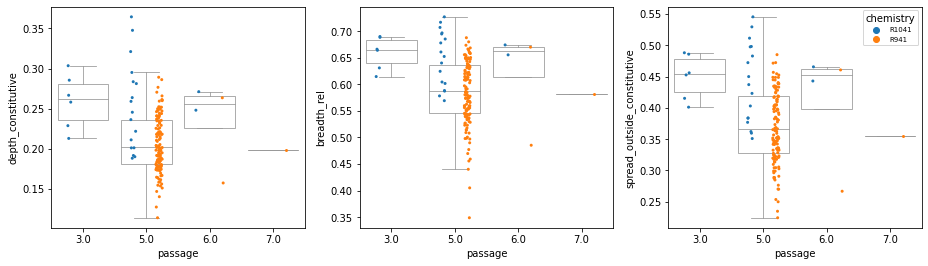

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, y in zip(axes, ['depth_constitutive', 'breadth_rel', 'spread_outside_constitutive']):
    sns.stripplot(data=m, x='passage', y=y, hue='chemistry', dodge=True, size=3, ax=ax)
    sns.boxplot(data=m, x='passage', y=y, color='white', fliersize=0, ax=ax, linewidth=0.8)
    ax.legend([], frameon=False)
axes[-1].legend(*axes[0].get_legend_handles_labels(), title='chemistry', fontsize=7)
plt.tight_layout()
plt.savefig(f'{figdir}/qc13_pmd_metrics_by_passage.png', dpi=150)

In [20]:
m.groupby('passage')[['depth_constitutive', 'breadth_rel', 'spread_outside_constitutive']].agg(['size', 'median']).round(3)

depth_constitutive        breadth_rel         \
                      size median        size median   
passage                                                
3.0                      6  0.262           6  0.665   
5.0                    144  0.202         144  0.587   
6.0                      4  0.256           4  0.663   
7.0                      1  0.199           1  0.581   

        spread_outside_constitutive         
                               size median  
passage                                     
3.0                               6  0.454  
5.0                             144  0.367  
6.0                               4  0.452  
7.0                               1  0.354

### other categorical covariates

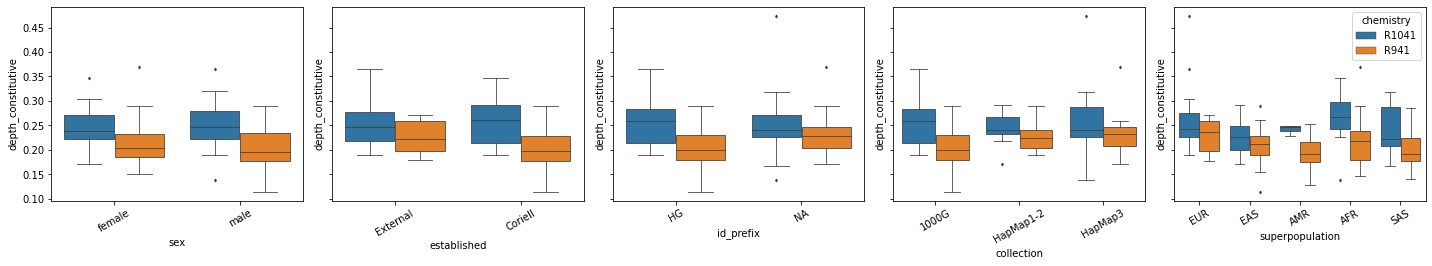

In [21]:
cats = ['sex', 'established', 'id_prefix', 'collection', 'superpopulation']
fig, axes = plt.subplots(1, len(cats), figsize=(4 * len(cats), 3.8), sharey=True)
for ax, c in zip(axes, cats):
    sns.boxplot(data=m, x=c, y='depth_constitutive', hue='chemistry', fliersize=2, ax=ax, linewidth=0.8)
    ax.tick_params(axis='x', rotation=30)
    if ax is not axes[-1]:
        ax.legend([], frameon=False)
plt.tight_layout()
plt.savefig(f'{figdir}/qc13_pmd_depth_by_metadata.png', dpi=150)

In [22]:
m.sort_values('depth_constitutive', ascending=False)[['sample', 'population', 'id_prefix', 'chemistry', 'passage', 'established', 'sex', 'depth_constitutive', 'breadth_rel', 'spread_outside_constitutive']].head(15)

,sample,population,id_prefix,chemistry,passage,established,sex,depth_constitutive,breadth_rel,spread_outside_constitutive
187,NA20762,TSI,NA,R1041,NaN,NaN,NaN,0.474582,0.769619,0.613572
174,NA19338,LWK,NA,R941,NaN,NaN,female,0.369875,0.733335,0.553412
11,HG00290,FIN,HG,R1041,5.0,External,male,0.364452,0.727001,0.545332
98,HG02583,GWD,HG,R1041,5.0,Coriell,female,0.347659,0.707076,0.511292
130,HG03521,ESN,HG,R1041,5.0,Coriell,male,0.321164,0.716799,0.529312
196,NA21093,GIH,NA,R1041,NaN,NaN,NaN,0.317462,0.713600,0.524608
193,NA20850,GIH,NA,R1041,NaN,NaN,male,0.306756,0.699078,0.508061
55,HG01786,IBS,HG,R1041,3.0,External,female,0.303555,0.688408,0.485687
176,NA19443,LWK,NA,R1041,NaN,NaN,male,0.301474,0.697622,0.502076
170,NA19036,LWK,NA,R1041,NaN,NaN,female,0.298613,0.693068,0.494414


### write outputs

In [23]:
m.to_csv(f'{outdir}/donor_pmd_expansion_metrics.tsv', sep='\t', index=False)
assoc.to_csv(f'{outdir}/pmd_metric_metadata_association.tsv', sep='\t', index=False)

In [24]:
!date

Thu Sep 17 10:45:02 PDT 2026
